In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_high=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68\GSDescriptor-Multimodal68.xlsx')
data_low=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633\GSDescriptor-Batch633.xlsx')

In [3]:
data_high.head()

,ID,Original_SMILES,hlg_kjmol,ci_index,dipole_gs_debye
0,1,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,583.646820,0.450706,1.0452
1,2,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,594.804455,0.401488,1.7827
2,3,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,595.367222,0.757638,0.3812
3,4,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,569.684733,0.796902,1.2060
4,5,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,563.845685,0.672074,2.7429


In [4]:
data_low.head()

,ID,Original_SMILES,hlg_kjmol,ci_index,dipole_gs_debye
0,1,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,79.329967,0.425218,2.764
1,2,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,83.662143,0.305465,2.807
2,3,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,105.641426,0.817238,0.429
3,4,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,104.145909,0.850383,0.784
4,5,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,86.537396,0.394855,4.389


In [5]:
properties = ['hlg_kjmol', 'ci_index', 'dipole_gs_debye']

cols_needed = ['ID'] + properties

data_high = data_high[cols_needed]
data_low = data_low[cols_needed]

# === 按 ID 合并（inner 保证只有 68 个重叠分子）===
df = pd.merge(
    data_high, data_low,
    on='ID',
    suffixes=('_high', '_low'),
    how='inner'
)

print(f"Number of matched molecules: {len(df)}")

Number of matched molecules: 68


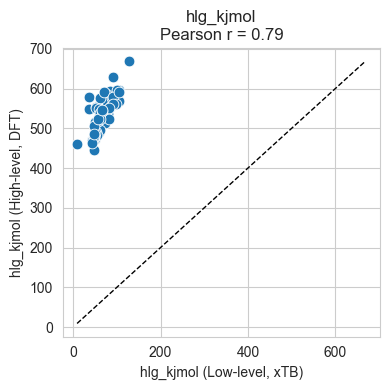

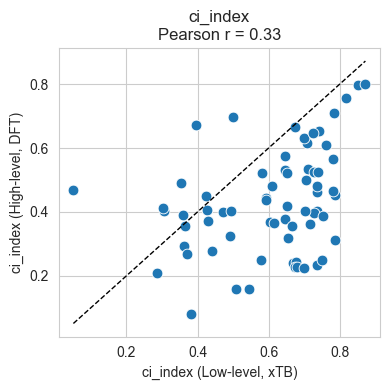

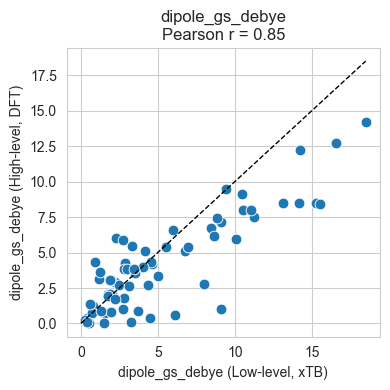

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_style("whitegrid")

for prop in properties:
    x = df[f'{prop}_low']
    y = df[f'{prop}_high']
    
    r, _ = pearsonr(x, y)

    plt.figure(figsize=(4, 4))
    sns.scatterplot(x=x, y=y, s=60)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

    plt.xlabel(f'{prop} (Low-level, xTB)')
    plt.ylabel(f'{prop} (High-level, DFT)')
    plt.title(f'{prop}\nPearson r = {r:.2f}')
    plt.tight_layout()
    plt.show()


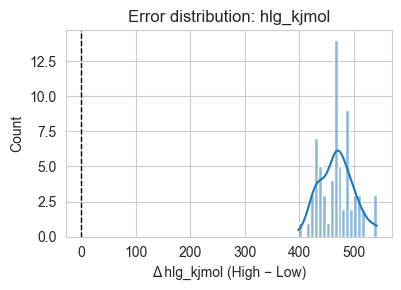

hlg_kjmol: mean Δ = 468.445, std Δ = 31.034, MAE = 468.445


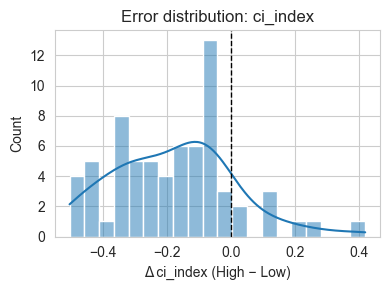

ci_index: mean Δ = -0.178, std Δ = 0.190, MAE = 0.216


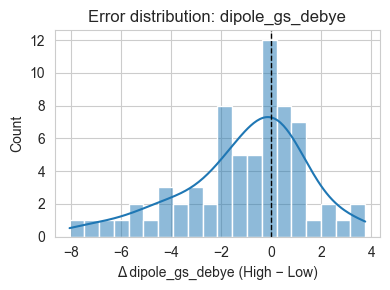

dipole_gs_debye: mean Δ = -1.084, std Δ = 2.471, MAE = 1.907


In [7]:
for prop in properties:
    df[f'delta_{prop}'] = df[f'{prop}_high'] - df[f'{prop}_low']

    # ===== 统计量 =====
    mean_delta = df[f'delta_{prop}'].mean()
    std_delta = df[f'delta_{prop}'].std()
    mae = df[f'delta_{prop}'].abs().mean()   # ← MAE

    # ===== 画分布 =====
    plt.figure(figsize=(4, 3))
    sns.histplot(df[f'delta_{prop}'], bins=20, kde=True)
    plt.axvline(0, color='k', linestyle='--', lw=1)
    
    plt.xlabel(f'Δ {prop} (High − Low)')
    plt.title(f'Error distribution: {prop}')
    plt.tight_layout()
    plt.show()

    # ===== 打印 =====
    print(
        f"{prop}: mean Δ = {mean_delta:.3f}, "
        f"std Δ = {std_delta:.3f}, "
        f"MAE = {mae:.3f}"
    )

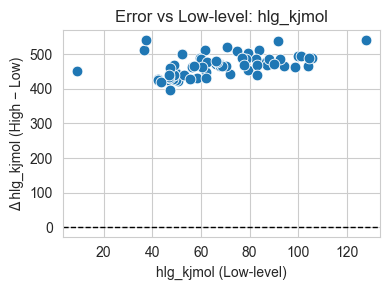

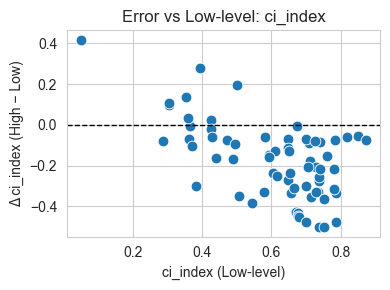

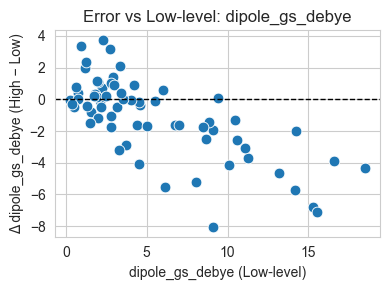

In [8]:
for prop in properties:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(
        x=df[f'{prop}_low'],
        y=df[f'delta_{prop}'],
        s=60
    )
    plt.axhline(0, color='k', linestyle='--', lw=1)

    plt.xlabel(f'{prop} (Low-level)')
    plt.ylabel(f'Δ {prop} (High − Low)')
    plt.title(f'Error vs Low-level: {prop}')
    plt.tight_layout()
    plt.show()


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression

for prop in properties:
    X = df[[f'{prop}_low']].values
    y = df[f'{prop}_high'].values

    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)   # 不用 squared 参数
    rmse = np.sqrt(mse)

    print(f'\n{prop}')
    print(f'  y = {lr.coef_[0]:.3f} * x + {lr.intercept_:.3f}')
    print(f'  MAE = {mae:.3f}, RMSE = {rmse:.3f}')



hlg_kjmol
  y = 1.682 * x + 422.535
  MAE = 21.003, RMSE = 27.347

ci_index
  y = 0.324 * x + 0.232
  MAE = 0.124, RMSE = 0.152

dipole_gs_debye
  y = 0.611 * x + 0.976
  MAE = 1.301, RMSE = 1.698


In [10]:
df

,ID,hlg_kjmol_high,ci_index_high,dipole_gs_debye_high,hlg_kjmol_low,ci_index_low,dipole_gs_debye_low,delta_hlg_kjmol,delta_ci_index,delta_dipole_gs_debye
0,1,583.646820,0.450706,1.0452,79.329967,0.425218,2.764,504.316853,0.025488,-1.7188
1,2,594.804455,0.401488,1.7827,83.662143,0.305465,2.807,511.142311,0.096024,-1.0243
2,3,595.367222,0.757638,0.3812,105.641426,0.817238,0.429,489.725796,-0.059600,-0.0478
3,4,569.684733,0.796902,1.2060,104.145909,0.850383,0.784,465.538824,-0.053481,0.4220
4,5,563.845685,0.672074,2.7429,86.537396,0.394855,4.389,477.308289,0.277219,-1.6461
...,...,...,...,...,...,...,...,...,...,...
63,64,538.632138,0.239904,8.0053,62.261770,0.669608,11.058,476.370368,-0.429705,-3.0527
64,65,543.457990,0.243815,8.4703,66.458868,0.676078,14.171,476.999122,-0.432263,-5.7007
65,66,522.256979,0.226858,8.5117,60.332071,0.675537,13.156,461.924909,-0.448679,-4.6443
66,67,524.297744,0.227695,8.4589,56.926150,0.678771,15.539,467.371594,-0.451076,-7.0801


### hlg_KJmol

In [11]:
import numpy as np
import pandas as pd

# Δ label
df['delta_hlg'] = df['hlg_kjmol_high'] - df['hlg_kjmol_low']


In [12]:
df_high_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68-SMILES+Label.xlsx')
df_low_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633_SMILES+Label.xlsx')

In [13]:
df['smiles']=df_high_SMILES['Original_SMILES']

In [14]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles, hlg_kjmol_low, delta_hlg
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_hlg"].values.astype(float)
hlg_low_all = df["hlg_kjmol_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=0,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

hlg_train_full = hlg_low_all[train_idx]
hlg_test = hlg_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([hlg_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([hlg_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerator
[15:52:41] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 14.32 kJ/mol
RMSE = 19.75 kJ/mol
R²   = 0.584

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 12.95 kJ/mol
RMSE = 15.45 kJ/mol
R²   = 0.773


In [15]:
# =========================
# 1) 准备数据：df 必须有 smiles, hlg_KJmol_low, hlg_KJmol_high, delta_hlg
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_hlg"].values.astype(float)
hlg_low_all = df["hlg_kjmol_low"].values.astype(float)
hlg_high_all = df["hlg_kjmol_high"].values.astype(float)   # ✅ 新增：真实高精度

# =========================
# 2) 90/10 split
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=0.10, random_state=0, shuffle=True)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

hlg_train_full = hlg_low_all[train_idx]
hlg_test = hlg_low_all[test_idx]

hlg_high_train_full = hlg_high_all[train_idx]  # ✅
hlg_high_test = hlg_high_all[test_idx]         # ✅

# =========================
# 3) top_indices on 90% train
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]

fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([hlg_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([hlg_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 5-fold CV on 90% train
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true_delta, cv_pred_delta = [], []
cv_true_high, cv_pred_high = [], []   # ✅ 新增：用于 high-level MAE

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    # 对应 low/high 真值（仅用于计算 high-level MAE，不参与训练）
    hlg_low_va = hlg_train_full[va_i]
    hlg_high_va = hlg_high_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat_delta = gpr.predict(X_va_s)

    # ✅ delta learning -> high-level prediction
    y_hat_high = hlg_low_va + y_hat_delta

    cv_true_delta.append(y_va)
    cv_pred_delta.append(y_hat_delta)

    cv_true_high.append(hlg_high_va)
    cv_pred_high.append(y_hat_high)

cv_true_delta = np.concatenate(cv_true_delta)
cv_pred_delta = np.concatenate(cv_pred_delta)
cv_true_high = np.concatenate(cv_true_high)
cv_pred_high = np.concatenate(cv_pred_high)

cv_mae_delta = mean_absolute_error(cv_true_delta, cv_pred_delta)
cv_rmse_delta = np.sqrt(mean_squared_error(cv_true_delta, cv_pred_delta))
cv_r2_delta = r2_score(cv_true_delta, cv_pred_delta)

cv_mae_high = mean_absolute_error(cv_true_high, cv_pred_high)  # ✅ 你要的
cv_rmse_high = np.sqrt(mean_squared_error(cv_true_high, cv_pred_high))

print("===== 5-fold CV on 90% train =====")
print(f"[Delta] MAE  = {cv_mae_delta:.2f} kJ/mol")
print(f"[Delta] RMSE = {cv_rmse_delta:.2f} kJ/mol")
print(f"[Delta] R²   = {cv_r2_delta:.3f}")
print(f"[High ] MAE  = {cv_mae_high:.2f} kJ/mol  (hlg_low + pred_delta vs true_high)")
print(f"[High ] RMSE = {cv_rmse_high:.2f} kJ/mol")

# =========================
# 5) train final model on 90% train, eval on 10% test
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

X_test_s = final_scaler.transform(X_test)
y_test_hat_delta = final_gpr.predict(X_test_s)

# ✅ delta learning -> high-level prediction on test
y_test_hat_high = hlg_test + y_test_hat_delta

test_mae_delta = mean_absolute_error(y_test, y_test_hat_delta)
test_rmse_delta = np.sqrt(mean_squared_error(y_test, y_test_hat_delta))
test_r2_delta = r2_score(y_test, y_test_hat_delta)

test_mae_high = mean_absolute_error(hlg_high_test, y_test_hat_high)  # ✅ 你要的
test_rmse_high = np.sqrt(mean_squared_error(hlg_high_test, y_test_hat_high))

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"[Delta] MAE  = {test_mae_delta:.2f} kJ/mol")
print(f"[Delta] RMSE = {test_rmse_delta:.2f} kJ/mol")
print(f"[Delta] R²   = {test_r2_delta:.3f}")
print(f"[High ] MAE  = {test_mae_high:.2f} kJ/mol  (hlg_low + pred_delta vs true_high)")
print(f"[High ] RMSE = {test_rmse_high:.2f} kJ/mol")

[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerator
[15:52:47] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
[Delta] MAE  = 14.32 kJ/mol
[Delta] RMSE = 19.75 kJ/mol
[Delta] R²   = 0.584
[High ] MAE  = 14.32 kJ/mol  (hlg_low + pred_delta vs true_high)
[High ] RMSE = 19.75 kJ/mol

===== Hold-out 10% Test (trained on 90%) =====
[Delta] MAE  = 12.95 kJ/mol
[Delta] RMSE = 15.45 kJ/mol
[Delta] R²   = 0.773
[High ] MAE  = 12.95 kJ/mol  (hlg_low + pred_delta vs true_high)
[High ] RMSE = 15.45 kJ/mol


In [16]:
data_low['smiles']=df_low_SMILES['Original_SMILES']
data_low["morgan_fp_with_freq"] = data_low["smiles"].apply(get_Morgan_fingerprint_frequency)
data_low = data_low.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["hlg_kjmol"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_hlg_pred"] = delta_pred
data_low["hlg_kjmol_high_pred"] = data_low["hlg_kjmol"].astype(float) + data_low["delta_hlg_pred"].astype(float)

[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerator
[15:52:54] DEPRECATION WARNING: please use MorganGenerat

In [17]:
data_low

,ID,hlg_kjmol,ci_index,dipole_gs_debye,smiles,morgan_fp_with_freq,delta_hlg_pred,hlg_kjmol_high_pred
0,1,79.329967,0.425218,2.764,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",501.429438,580.759405
1,2,83.662143,0.305465,2.807,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",509.931203,593.593347
2,3,105.641426,0.817238,0.429,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",486.390638,592.032064
3,4,104.145909,0.850383,0.784,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",469.589797,573.735706
4,5,86.537396,0.394855,4.389,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",477.249027,563.786424
...,...,...,...,...,...,...,...,...
627,629,105.959827,0.785626,0.895,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",458.802742,564.762569
628,630,73.888213,0.637715,16.646,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",482.750834,556.639047
629,631,41.189447,0.736174,2.001,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",466.055353,507.244799
630,632,36.992349,0.604572,3.330,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",479.015559,516.007908


In [18]:
data_GS_new_300=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Virtual300\GSDescriptor-Virtual300.xlsx')

In [ ]:
data_GS_new_300["morgan_fp_with_freq"] = data_GS_new_300["SMILES"].apply(get_Morgan_fingerprint_frequency)
data_GS_new_300 = data_GS_new_300.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_GS_new_300 = np.array(data_GS_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_GS_new_300_top = fp_GS_new_300[:, top_indices]
X_GS_new_300 = np.hstack([
    data_GS_new_300["hlg_kjmol"].values.astype(float).reshape(-1, 1),
    fp_GS_new_300_top.astype(float)
])
X_GS_new_300_s = final_scaler.transform(X_GS_new_300)
delta_pred = final_gpr.predict(X_GS_new_300_s)
data_GS_new_300["delta_hlg_pred"] = delta_pred
data_GS_new_300["hlg_kjmol_high_pred"] = data_GS_new_300["hlg_kjmol"].astype(float) + data_GS_new_300["delta_hlg_pred"].astype(float)

[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerator
[16:00:31] DEPRECATION WARNING: please use MorganGenerat

In [21]:
data_GS_new_300

,mol_id,SMILES,hlg_kjmol,ci_index,dipole_gs_debye,morgan_fp_with_freq,delta_hlg_pred,hlg_kjmol_high_pred
0,1,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,32.033130,0.663699,8.799,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",491.724121,523.757251
1,2,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,59.618287,0.674771,10.574,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ...",481.745598,541.363885
2,3,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,20.416296,0.664382,13.824,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",460.447046,480.863342
3,4,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,36.442510,0.682095,13.868,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",455.134858,491.577368
4,5,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,60.949784,0.678172,11.150,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",483.313812,544.263596
...,...,...,...,...,...,...,...,...
295,296,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,34.754017,0.659103,5.616,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",467.883635,502.637652
296,297,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,30.527959,0.676634,13.064,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",468.153152,498.681111
297,298,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,39.925630,0.667403,2.629,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",468.468525,508.394156
298,299,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,36.944234,0.676792,12.286,"[0, 0, 0, 0, 0, 0, 4, 0, 2, 0, 0, 0, 0, 0, 0, ...",473.483758,510.427992


### 2. CI_norm_overlap

### 3. Dipole_Moment_Debye

In [22]:
df

,ID,hlg_kjmol_high,ci_index_high,dipole_gs_debye_high,hlg_kjmol_low,ci_index_low,dipole_gs_debye_low,delta_hlg_kjmol,delta_ci_index,delta_dipole_gs_debye,delta_hlg,smiles,morgan_fp_with_freq
0,1,583.646820,0.450706,1.0452,79.329967,0.425218,2.764,504.316853,0.025488,-1.7188,504.316853,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,594.804455,0.401488,1.7827,83.662143,0.305465,2.807,511.142311,0.096024,-1.0243,511.142311,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,595.367222,0.757638,0.3812,105.641426,0.817238,0.429,489.725796,-0.059600,-0.0478,489.725796,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ..."
3,4,569.684733,0.796902,1.2060,104.145909,0.850383,0.784,465.538824,-0.053481,0.4220,465.538824,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5,563.845685,0.672074,2.7429,86.537396,0.394855,4.389,477.308289,0.277219,-1.6461,477.308289,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,538.632138,0.239904,8.0053,62.261770,0.669608,11.058,476.370368,-0.429705,-3.0527,476.370368,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
64,65,543.457990,0.243815,8.4703,66.458868,0.676078,14.171,476.999122,-0.432263,-5.7007,476.999122,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
65,66,522.256979,0.226858,8.5117,60.332071,0.675537,13.156,461.924909,-0.448679,-4.6443,461.924909,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
66,67,524.297744,0.227695,8.4589,56.926150,0.678771,15.539,467.371594,-0.451076,-7.0801,467.371594,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [23]:
df['delta_dmd'] = df['dipole_gs_debye_high'] - df['dipole_gs_debye_low']
# =========================
# 1) 准备数据：df 必须有 smiles, dipole_gs_debye_low, delta_dmd
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_dmd"].values.astype(float)
dmd_low_all = df["dipole_gs_debye_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=1,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

dmd_train_full = dmd_low_all[train_idx]
dmd_test = dmd_low_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([dmd_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([dmd_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:03:10] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerator
[16:03:11] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 1.27 kJ/mol
RMSE = 1.74 kJ/mol
R²   = 0.501

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.95 kJ/mol
RMSE = 1.12 kJ/mol
R²   = 0.758


In [24]:
#data_low['smiles']=df_low_SMILES['Original_SMILES']
data_low["morgan_fp_with_freq"] = data_low["smiles"].apply(get_Morgan_fingerprint_frequency)
data_low = data_low.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["dipole_gs_debye"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low["delta_dmd_pred"] = delta_pred
data_low["dipole_gs_debye_high_pred"] = data_low["dipole_gs_debye"].astype(float) + data_low["delta_dmd_pred"].astype(float)

[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerator
[16:03:17] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
#data_low.to_excel(r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\GS_data_low_with_predictions.xlsx')

In [25]:
data_GS_new_300["morgan_fp_with_freq"] = data_GS_new_300["SMILES"].apply(get_Morgan_fingerprint_frequency)
data_GS_new_300 = data_GS_new_300.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
fp_GS_new_300 = np.array(data_GS_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_GS_new_300_top = fp_GS_new_300[:, top_indices]
X_GS_new_300 = np.hstack([
    data_GS_new_300["dipole_gs_debye"].values.astype(float).reshape(-1, 1),
    fp_GS_new_300_top.astype(float)
])
X_GS_new_300_s = final_scaler.transform(X_GS_new_300)
delta_pred = final_gpr.predict(X_GS_new_300_s)
data_GS_new_300["delta_dmd_pred"] = delta_pred
data_GS_new_300["dipole_gs_debye_high_pred"] = data_GS_new_300["dipole_gs_debye"].astype(float) + data_GS_new_300["delta_dmd_pred"].astype(float)

[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerator
[16:09:33] DEPRECATION WARNING: please use MorganGenerat

In [26]:
data_GS_new_300.to_excel(r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\virtual_300\GS_Virtual300_with_predictions.xlsx', index=False)

In [27]:
# 定义你要筛选的 mol_id 列表
target_ids = [28, 88, 139]

# 定义你需要提取的列名
target_columns = ['mol_id', 'SMILES', 'hlg_kjmol_high_pred', 'dipole_gs_debye_high_pred']

# 使用 .loc 进行精确的行筛选和列提取（推荐写法，效率高且规范）
result_df = data_GS_new_300.loc[data_GS_new_300['mol_id'].isin(target_ids), target_columns]

# 查看结果
result_df

,mol_id,SMILES,hlg_kjmol_high_pred,dipole_gs_debye_high_pred
27,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,510.069241,10.895163
87,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,494.992589,13.393643
138,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,511.770771,9.301823
